# Multi-swarm approximation in 2D

This notebook compares two Gaussian-mixture approximations of the same 2D target Gaussian mixture model.

- **BW-GMM gradient flow:** evolves a mixture of Gaussian particles directly through the variational flow.
- **Multi-swarm KL-LBW-CBO:** evolves several swarms and tracks the barycenter of each swarm, which defines a second Gaussian mixture approximation.

The experiment uses a shared Gaussian initialization, tracks the KL divergence of the induced mixture over time, and ends with two plots:
1. the final configurations of both approximations, and
2. the KL evolution in a separate figure.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

from gmm_target import GMM2D
from sigma_points import unscented_points
from plotting import plot_gmm_contours, ellipse_points

from cbo import GaussianParticle
from variational_gp import VGPConfig
from variational_gmm_bw import VariationalGMMBW
from cbo_multi_swarm import MultiSwarmKLLBWCBO, MultiSwarmCBOConfig


# ===========================
# Linear-algebra helpers
# ===========================
def _sym(A):
    return 0.5 * (A + A.T)

def _logsumexp(a):
    a = np.asarray(a, dtype=float)
    amax = np.max(a)
    return amax + np.log(np.sum(np.exp(a - amax)))

def _logsumexp_axis0(A):
    amax = np.max(A, axis=0, keepdims=True)
    return np.squeeze(amax, axis=0) + np.log(np.sum(np.exp(A - amax), axis=0))

def gaussian_logpdf(x, m, S):
    """log N(x | m, S)."""
    x = np.asarray(x, dtype=float)
    m = np.asarray(m, dtype=float)
    S = _sym(np.asarray(S, dtype=float))

    d = m.size
    sign, logdet = np.linalg.slogdet(S)
    if sign <= 0:
        raise ValueError("Covariance is not SPD in gaussian_logpdf.")

    dx = x - m
    sol = np.linalg.solve(S, dx)
    return -0.5 * (d * np.log(2.0 * np.pi) + logdet + dx @ sol)

def gaussian_score(x, m, S):
    """∇ log N(x | m, S)."""
    x = np.asarray(x, dtype=float)
    m = np.asarray(m, dtype=float)
    S = _sym(np.asarray(S, dtype=float))
    return -np.linalg.solve(S, x - m)

def _gaussian_logpdf_grid(XY, m, S, eps=1e-12):
    """Vectorized log N(x | m, S) on a 2D grid with XY of shape (..., 2)."""
    S = _sym(np.asarray(S, dtype=float))
    m = np.asarray(m, dtype=float)

    w, U = np.linalg.eigh(S)
    w = np.clip(w, eps, None)
    logdet = np.log(w).sum()

    DX = XY - m
    Y = np.einsum('...i,ij->...j', DX, U)
    quad = np.sum((Y * Y) / w, axis=-1)

    d = m.size
    return -0.5 * (d * np.log(2.0 * np.pi) + logdet + quad)

def _extract_target_components(gmm):
    """Extract weights, means, and covariances from supported GMM target classes."""
    comps = gmm.components

    if len(comps) == 6 and np.isscalar(comps[0]):
        w1, m1, S1, w2, m2, S2 = comps
        ws = np.array([w1, w2], dtype=float)
        ms = np.stack([np.asarray(m1, float), np.asarray(m2, float)], axis=0)
        Ss = np.stack([np.asarray(S1, float), np.asarray(S2, float)], axis=0)
        return ws, ms, Ss

    if len(comps) == 3:
        ws, ms, Ss = comps
        return np.asarray(ws, float), np.asarray(ms, float), np.asarray(Ss, float)

    raise ValueError("Unsupported target format in _extract_target_components.")

def _target_logpdf_grid(XY, gmm):
    ws, ms, Ss = _extract_target_components(gmm)
    logs = np.stack(
        [np.log(ws[k]) + _gaussian_logpdf_grid(XY, ms[k], Ss[k]) for k in range(len(ws))],
        axis=0,
    )
    return _logsumexp_axis0(logs)

def _mixture_logpdf_grid(XY, M, S):
    N = M.shape[0]
    logs = np.stack(
        [np.log(1.0 / N) + _gaussian_logpdf_grid(XY, M[k], S[k]) for k in range(N)],
        axis=0,
    )
    return _logsumexp_axis0(logs)

def _auto_box_2d(M, S, gmm, nsig=7.0, pad=1.0):
    """Automatic integration box from both the approximation mixture and the target."""
    ws_t, ms_t, Ss_t = _extract_target_components(gmm)

    all_m = list(np.asarray(M)) + [np.asarray(m) for m in ms_t]
    all_S = list(np.asarray(S)) + [np.asarray(C) for C in Ss_t]

    xmin, xmax = np.inf, -np.inf
    ymin, ymax = np.inf, -np.inf

    for m, C in zip(all_m, all_S):
        C = _sym(C)
        std = np.sqrt(np.clip(np.diag(C), 1e-14, None))
        xmin = min(xmin, m[0] - nsig * std[0])
        xmax = max(xmax, m[0] + nsig * std[0])
        ymin = min(ymin, m[1] - nsig * std[1])
        ymax = max(ymax, m[1] + nsig * std[1])

    return (xmin - pad, xmax + pad), (ymin - pad, ymax + pad)

def KL_mix_exact_2d(
    M, S, gmm, nx=801, ny=801, xlim=None, ylim=None, nsig=7.0, pad=1.0, return_diagnostics=False
):
    """High-accuracy 2D quadrature for KL(P_mu || pi) on a fine grid."""
    M = np.asarray(M, dtype=float)
    S = np.asarray(S, dtype=float)

    if xlim is None or ylim is None:
        xlim_auto, ylim_auto = _auto_box_2d(M, S, gmm, nsig=nsig, pad=pad)
        xlim = xlim_auto if xlim is None else xlim
        ylim = ylim_auto if ylim is None else ylim

    xs = np.linspace(xlim[0], xlim[1], nx)
    ys = np.linspace(ylim[0], ylim[1], ny)
    dx = xs[1] - xs[0]
    dy = ys[1] - ys[0]

    wx = np.ones(nx)
    wy = np.ones(ny)
    wx[0] = wx[-1] = 0.5
    wy[0] = wy[-1] = 0.5
    W = np.outer(wy, wx) * dx * dy

    X, Y = np.meshgrid(xs, ys, indexing='xy')
    XY = np.stack([X, Y], axis=-1)

    logP = _mixture_logpdf_grid(XY, M, S)
    logpi = _target_logpdf_grid(XY, gmm)

    P = np.exp(logP)
    pi = np.exp(logpi)

    kl = np.sum(W * P * (logP - logpi))
    mass_P = np.sum(W * P)
    mass_pi = np.sum(W * pi)

    if return_diagnostics:
        return float(kl), {
            "xlim": xlim,
            "ylim": ylim,
            "nx": nx,
            "ny": ny,
            "mass_P_on_grid": float(mass_P),
            "mass_pi_on_grid": float(mass_pi),
        }

    return float(kl)


In [7]:
# ==========================================================
# Target and shared initialization
# ==========================================================
gmm = GMM2D(
    w1=0.5,
    m1=(-2.0, 0.0), S1=(2, 0.0, 0.0, 0.5),
    m2=(2.0, 0.0),  S2=(1, -0.0, -0.0, 2),
)

m0 = np.array([0.0, 0.0], dtype=float)
S0 = np.array([[1.0, 0.0],
               [0.0, 1.0]], dtype=float)

rng = np.random.default_rng(0)
d = 2
n_particles = 10
steps = 100
dt = 0.05


# ==========================================================
# Target and mixture utilities
# ==========================================================
def target_gradV(x):
    return gmm.gradV(x)

def target_logpdf(x):
    if hasattr(gmm, "logpdf"):
        return float(gmm.logpdf(x))
    if hasattr(gmm, "logp"):
        return float(gmm.logp(x))
    if hasattr(gmm, "pdf"):
        return np.log(max(float(gmm.pdf(x)), 1e-300))
    if hasattr(gmm, "V"):
        return -float(gmm.V(x))
    raise AttributeError("Need one of gmm.logpdf, gmm.logp, gmm.pdf, or gmm.V to evaluate KL.")

def target_potential(x):
    return -target_logpdf(x)

def mixture_logpdf(x, M, S):
    """Log-density of the equal-weight Gaussian mixture P_mu."""
    N = M.shape[0]
    logs = np.array(
        [np.log(1.0 / N) + gaussian_logpdf(x, M[j], S[j]) for j in range(N)],
        dtype=float,
    )
    return _logsumexp(logs)

def mixture_score(x, M, S):
    """Score ∇ log P_mu(x) computed from mixture responsibilities."""
    N = M.shape[0]
    logs = np.array(
        [np.log(1.0 / N) + gaussian_logpdf(x, M[j], S[j]) for j in range(N)],
        dtype=float,
    )

    lse = _logsumexp(logs)
    r = np.exp(logs - lse)

    scores = np.array([gaussian_score(x, M[j], S[j]) for j in range(N)], dtype=float)
    return np.tensordot(r, scores, axes=(0, 0))

def expect_scalar_ut(f, m, S, alpha=1.0, beta=2.0, kappa=0.0):
    pts, Wm, _ = unscented_points(m, S, alpha=alpha, beta=beta, kappa=kappa)
    val = 0.0
    for w, x in zip(Wm, pts):
        val += w * f(x)
    return float(val)

def KL_mix(M, S, alpha=1.0, beta=2.0, kappa=0.0):
    """Unscented-transform approximation of KL(P_mu || p)."""
    N = M.shape[0]
    out = 0.0
    for i in range(N):
        pts, Wm, _ = unscented_points(M[i], S[i], alpha=alpha, beta=beta, kappa=kappa)
        for w, x in zip(Wm, pts):
            out += (1.0 / N) * w * (mixture_logpdf(x, M, S) - target_logpdf(x))
    return float(out)


# ==========================================================
# Initial Gaussian mixture approximation
# ==========================================================
M0 = np.stack([m0 + 0.2 * rng.normal(size=d) for _ in range(n_particles)], axis=0)
S0_particles = np.repeat(S0[None, :, :], n_particles, axis=0)


# ==========================================================
# 1) BW-GMM gradient flow
# ==========================================================
def expect_grad_ut_gmm(M, S, alpha=1.0, beta=2.0, kappa=0.0):
    """Expectation of the score mismatch under each Gaussian component."""
    N, d = M.shape
    G = np.zeros((N, d), dtype=float)

    for i in range(N):
        pts, Wm, _ = unscented_points(M[i], S[i], alpha=alpha, beta=beta, kappa=kappa)
        gi = np.zeros(d, dtype=float)
        for w, x in zip(Wm, pts):
            gi += w * (mixture_score(x, M, S) + target_gradV(x))
        G[i] = gi

    return G

def expect_cross_ut_gmm(M, S, alpha=1.0, beta=2.0, kappa=0.0):
    """Cross moment appearing in the BW-GMM covariance update."""
    N, d = M.shape
    C = np.zeros((N, d, d), dtype=float)

    for i in range(N):
        pts, Wm, _ = unscented_points(M[i], S[i], alpha=alpha, beta=beta, kappa=kappa)
        Ci = np.zeros((d, d), dtype=float)
        for w, x in zip(Wm, pts):
            dx = x - M[i]
            force = mixture_score(x, M, S) + target_gradV(x)
            Ci += w * np.outer(force, dx)
        C[i] = Ci

    return C

vgmm = VariationalGMMBW(
    expect_grad=lambda M, S: expect_grad_ut_gmm(M, S, alpha=1.0),
    expect_cross=lambda M, S: expect_cross_ut_gmm(M, S, alpha=1.0),
    cfg=VGPConfig(dt=dt, steps=steps, seed=0),
    flow_scale=1.0,
)

traj_bw = vgmm.run(M0, S0_particles)
M_path_bw = np.stack([M for (M, _) in traj_bw], axis=0)
t_bw = np.arange(len(traj_bw)) * vgmm.cfg.dt
KL_bw = np.array([KL_mix(M, S) for (M, S) in traj_bw], dtype=float)


# ==========================================================
# 2) Multi-swarm KL-LBW-CBO
# ==========================================================
def quad_rule_ut(m, S, alpha=1.0, beta=2.0, kappa=0.0):
    pts, Wm, _ = unscented_points(m, S, alpha=alpha, beta=beta, kappa=kappa)
    return pts, Wm

def rand_diag_tangent(low=-0.1, high=0.1):
    lam1, lam2 = rng.uniform(low, high, size=2)
    return np.array([[lam1, 0.0],
                     [0.0,  lam2]], dtype=float)

K = 4
particles_per_swarm = 10

swarms = []
for _ in range(K):
    swarm_k = []
    for _ in range(particles_per_swarm):
        m_i = m0 + 0.2 * rng.normal(size=d)
        V_i = rand_diag_tangent(-0.5, 0.5)
        swarm_k.append(GaussianParticle(m_i, V_i))
    swarms.append(swarm_k)

mscbo_cfg = MultiSwarmCBOConfig(
    alpha=1e4,
    sigma=5,
    lmbda=1.0,
    dt=dt,
    seed=0,
    n_update_base=0,
)

mscbo = MultiSwarmKLLBWCBO(
    potential=target_potential,
    quad_rule=lambda m, S: quad_rule_ut(m, S, alpha=1.0, beta=2.0, kappa=0.0),
    cfg=mscbo_cfg,
)

traj_ms, swarms_final = mscbo.run(swarms, steps=steps)
t_ms = np.arange(len(traj_ms)) * mscbo.cfg.dt

M_path_ms = np.stack(
    [np.stack([traj_ms[t][k][0] for k in range(K)], axis=0) for t in range(len(traj_ms))],
    axis=0,
)

S_path_ms = np.stack(
    [np.stack([traj_ms[t][k][1] for k in range(K)], axis=0) for t in range(len(traj_ms))],
    axis=0,
)

KL_ms = np.array(
    [KL_mix(M_path_ms[t], S_path_ms[t]) for t in range(len(traj_ms))],
    dtype=float,
)


# ==========================================================
# Final exact KL values on a fine 2D grid
# ==========================================================
M_fin_bw, S_fin_bw = traj_bw[-1]
KL_bw_final_exact, diag_bw = KL_mix_exact_2d(
    M_fin_bw,
    S_fin_bw,
    gmm,
    nx=801,
    ny=801,
    return_diagnostics=True,
)

M_fin_ms = M_path_ms[-1]
S_fin_ms = S_path_ms[-1]
KL_ms_final_exact, diag_ms = KL_mix_exact_2d(
    M_fin_ms,
    S_fin_ms,
    gmm,
    nx=801,
    ny=801,
    return_diagnostics=True,
)

print(f"BW-GMM-GF mixture:                    KL initial={KL_bw[0]:.6g}, final={KL_bw[-1]:.6g}")
print(f"Multi-swarm KL-LBW-CBO barycenter mix: KL initial={KL_ms[0]:.6g}, final={KL_ms[-1]:.6g}")
print(f"Final exact KL, BW-GMM flow:           {KL_bw_final_exact:.8g}")
print(f"Final exact KL, Multi-swarm CBO:       {KL_ms_final_exact:.8g}")


BW-GMM-GF mixture:                    KL initial=0.927217, final=-0.0887446
Multi-swarm KL-LBW-CBO barycenter mix: KL initial=0.778262, final=-0.229194
Final exact KL, BW-GMM flow:           0.15691174
Final exact KL, Multi-swarm CBO:       0.15783192


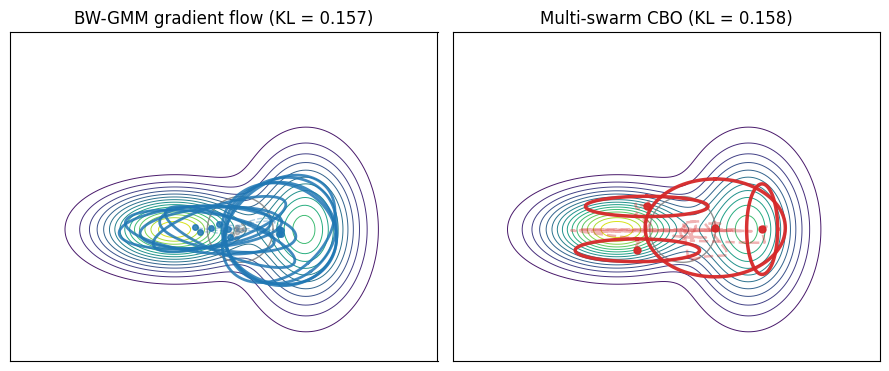

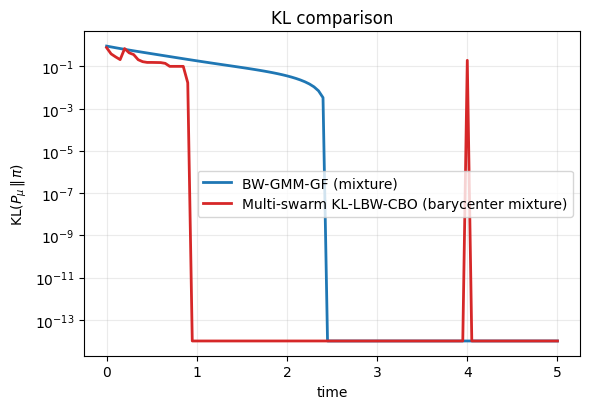

In [ ]:
# ==========================================================
# Visualization
# ==========================================================
# Figure 1: final configurations
fig1, axes = plt.subplots(1, 2, figsize=(9, 4))
ax_gf, ax_cbo = axes

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

xlim = (-7, 6)
ylim = (-4, 6)
pts0 = ellipse_points(m0, S0)

# BW-GMM gradient flow
plot_gmm_contours(ax_gf, gmm, xlim=xlim, ylim=ylim, n=150, levels=15)
ax_gf.set_title(f'BW-GMM gradient flow (KL = {KL_bw_final_exact:.3f})')
ax_gf.set_aspect('equal', adjustable='box')
ax_gf.autoscale(enable=False)
ax_gf.plot(pts0[:, 0], pts0[:, 1], lw=1.0, color='gray', alpha=0.85)
ax_gf.plot(M0[:, 0], M0[:, 1], 'o', ms=3, color='gray', alpha=0.5)

for i in range(n_particles):
    ax_gf.plot(
        M_path_bw[:, i, 0],
        M_path_bw[:, i, 1],
        '--',
        lw=1.0,
        color='tab:blue',
        alpha=0.35,
    )

for i in range(n_particles):
    pts_i = ellipse_points(M_fin_bw[i], S_fin_bw[i])
    ax_gf.plot(pts_i[:, 0], pts_i[:, 1], lw=2.0, color='tab:blue', alpha=0.85)
    ax_gf.plot(M_fin_bw[i, 0], M_fin_bw[i, 1], 'o', ms=4, color='tab:blue', alpha=0.85)

ax_gf.grid(False)

# Multi-swarm KL-LBW-CBO
plot_gmm_contours(ax_cbo, gmm, xlim=xlim, ylim=ylim, n=150, levels=15)
ax_cbo.set_title(f'Multi-swarm CBO (KL = {KL_ms_final_exact:.3f})')
ax_cbo.set_aspect('equal', adjustable='box')
ax_cbo.autoscale(enable=False)
ax_cbo.plot(pts0[:, 0], pts0[:, 1], lw=1.0, color='gray', alpha=0.85)

for k in range(K):
    ax_cbo.plot(
        M_path_ms[:, k, 0],
        M_path_ms[:, k, 1],
        '--',
        lw=1.8,
        color='tab:red',
        alpha=0.35,
    )

for k in range(K):
    pts_k = ellipse_points(M_fin_ms[k], S_fin_ms[k])
    ax_cbo.plot(pts_k[:, 0], pts_k[:, 1], lw=2.5, color='tab:red', alpha=0.95)
    ax_cbo.plot(M_fin_ms[k, 0], M_fin_ms[k, 1], 'o', ms=5, color='tab:red', alpha=0.95)

ax_cbo.grid(False)

plt.tight_layout()
#fig1.savefig("fig_2D_multiswarm_final.pdf", bbox_inches='tight')
plt.show()


# Figure 2: KL divergence over time
fig2, ax_kl = plt.subplots(1, 1, figsize=(6.0, 4.2))

eps = 1e-14
KL_bw_plot = np.maximum(KL_bw, eps)
KL_ms_plot = np.maximum(KL_ms, eps)

ax_kl.plot(t_bw, KL_bw_plot, lw=2.0, color='tab:blue', label='BW-GMM-GF (mixture)')
ax_kl.plot(t_ms, KL_ms_plot, lw=2.0, color='tab:red', label='Multi-swarm KL-LBW-CBO (barycenter mixture)')

ax_kl.set_title('KL comparison')
ax_kl.set_xlabel('time')
ax_kl.set_ylabel(r'$\mathrm{KL}(P_\mu \,\|\, \pi)$')
ax_kl.set_yscale('log')
ax_kl.grid(True, alpha=0.25)
ax_kl.legend(frameon=True)

plt.tight_layout()
#fig2.savefig("fig_2D_multiswarm_kl.pdf", bbox_inches='tight')
plt.show()
